In [10]:
import pandas as pd
import numpy as np
import glob

# 1. Troviamo tutti i file CSV nella cartella
files = glob.glob("ebay_iphone_*.csv")
lista_df = []

# 2. Funzione per estrarre lo Storage
def estrai_storage(titolo):
    titolo = str(titolo).upper()
    if '64GB' in titolo or '64 GB' in titolo: return '64GB'
    elif '256GB' in titolo or '256 GB' in titolo: return '256GB'
    elif '512GB' in titolo or '512 GB' in titolo: return '512GB'
    elif '128GB' in titolo or '128 GB' in titolo: return '128GB'
    return 'Sconosciuto'

# 3. Leggiamo e puliamo ogni file
for f in files:
    df_temp = pd.read_csv(f)
    
    # Estraiamo il modello dal nome del file per non perderlo
    modello = f.replace("ebay_", "").replace(".csv", "").replace("_", " ").upper()
    df_temp['Modello'] = modello
    
    # Pulizia Prezzo (gestione range "to" e simboli)
    df_temp['Price_Clean'] = df_temp['Price'].str.split(' to ').str[0]
    df_temp['Price_Clean'] = df_temp['Price_Clean'].str.replace('$', '', regex=False).str.replace(',', '', regex=False)
    df_temp['Price_Clean'] = pd.to_numeric(df_temp['Price_Clean'], errors='coerce')
    
    # Estrazione Storage
    df_temp['Storage'] = df_temp['Title'].apply(estrai_storage)
    
    lista_df.append(df_temp)

# 4. Uniamo tutto in un unico grande DataFrame
df_totale = pd.concat(lista_df, ignore_index=True)

# Vegliamo un'anteprima dei dati aggregati per modello
print(df_totale.groupby('Modello')['Price_Clean'].agg(['mean', 'count']))

                          mean  count
Modello                              
IPHONE 11 PRO MAX   422.844688    192
IPHONE 12 PRO MAX   561.462847    288
IPHONE 13 PRO MAX   707.821587    189
IPHONE 14 PRO MAX  1019.255005   1023
IPHONE XR           326.453750    480


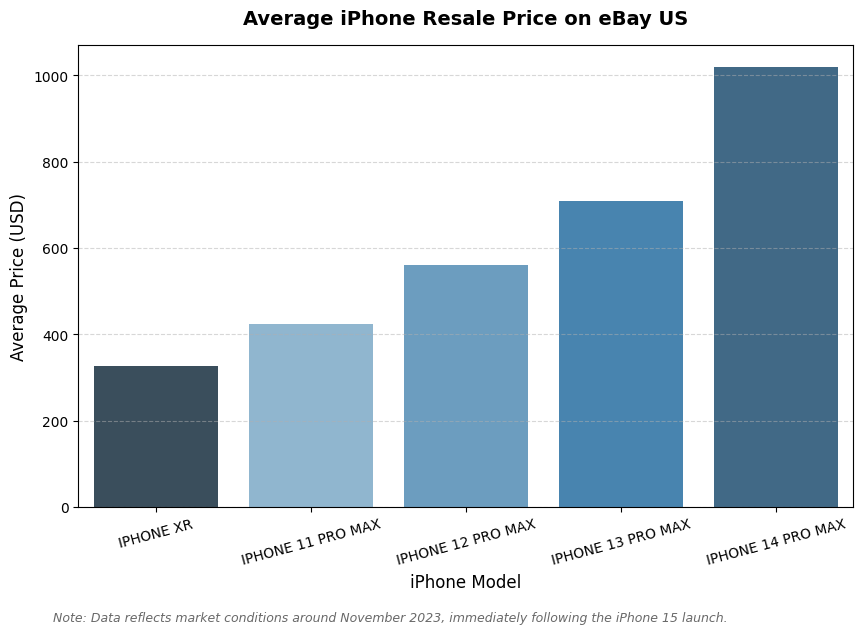

In [11]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Correct model order from oldest to newest
model_order = ['IPHONE XR', 'IPHONE 11 PRO MAX', 'IPHONE 12 PRO MAX', 'IPHONE 13 PRO MAX', 'IPHONE 14 PRO MAX']

# Generate the bar plot (FutureWarning fixed)
ax = sns.barplot(
    x='Modello', 
    y='Price_Clean', 
    data=df_totale, 
    order=model_order, 
    hue='Modello', 
    palette='Blues_d', 
    legend=False, 
    errorbar=None
)

# English titles and labels
plt.title('Average iPhone Resale Price on eBay US', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('iPhone Model', fontsize=12)
plt.ylabel('Average Price (USD)', fontsize=12)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Short, clean footnote
short_footnote = "Note: Data reflects market conditions around November 2023, immediately following the iPhone 15 launch."
plt.figtext(0.1, -0.08, short_footnote, fontsize=9, style='italic', color='dimgray')

plt.show()

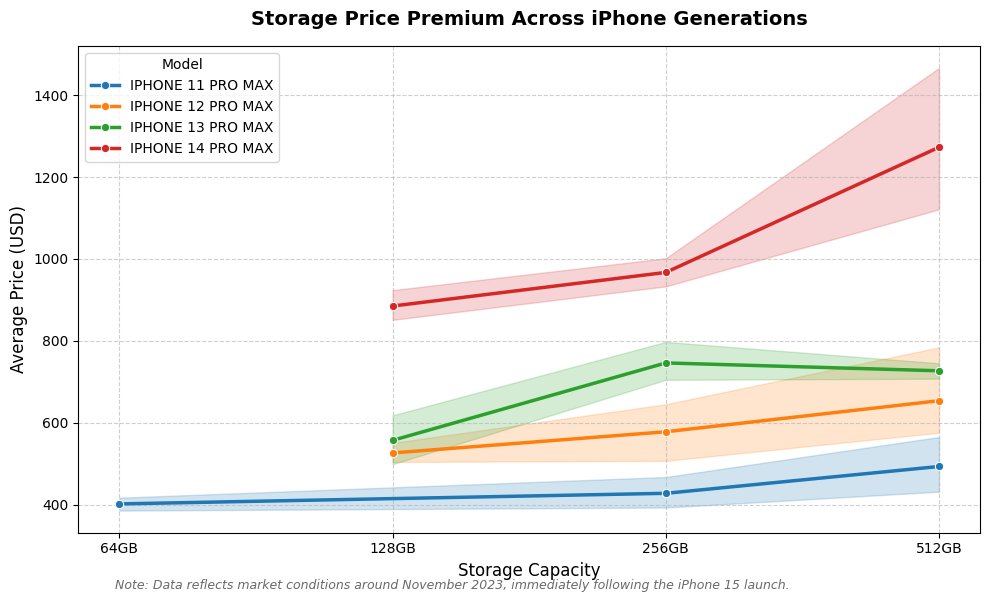

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter valid data and exclude iPhone XR (since it has different storage logic)
df_pro_max = df_totale[(df_totale['Storage'] != 'Sconosciuto') & (df_totale['Modello'] != 'IPHONE XR')].copy()

# 2. Tell Python the exact logical order for the GB tiers so it stops guessing!
storage_order = ['64GB', '128GB', '256GB', '512GB']
df_pro_max['Storage'] = pd.Categorical(df_pro_max['Storage'], categories=storage_order, ordered=True)

# 3. Sort the dataframe by this new order so the lines connect smoothly from left to right
df_pro_max = df_pro_max.sort_values('Storage')

# 4. Setup the plot
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_pro_max, 
    x='Storage', 
    y='Price_Clean', 
    hue='Modello', 
    marker='o', 
    linewidth=2.5,
    hue_order=['IPHONE 11 PRO MAX', 'IPHONE 12 PRO MAX', 'IPHONE 13 PRO MAX', 'IPHONE 14 PRO MAX']
)

# English titles, labels, and styling
plt.title('Storage Price Premium Across iPhone Generations', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Storage Capacity', fontsize=12)
plt.ylabel('Average Price (USD)', fontsize=12)
plt.legend(title='Model')
plt.grid(True, linestyle='--', alpha=0.6)

# Ensure layout handles everything gracefully
plt.tight_layout()

# 5. Add our short, crisp English footnote right below the layout
short_footnote = "Note: Data reflects market conditions around November 2023, immediately following the iPhone 15 launch."
plt.figtext(0.12, 0.01, short_footnote, fontsize=9, style='italic', color='dimgray')

plt.show()

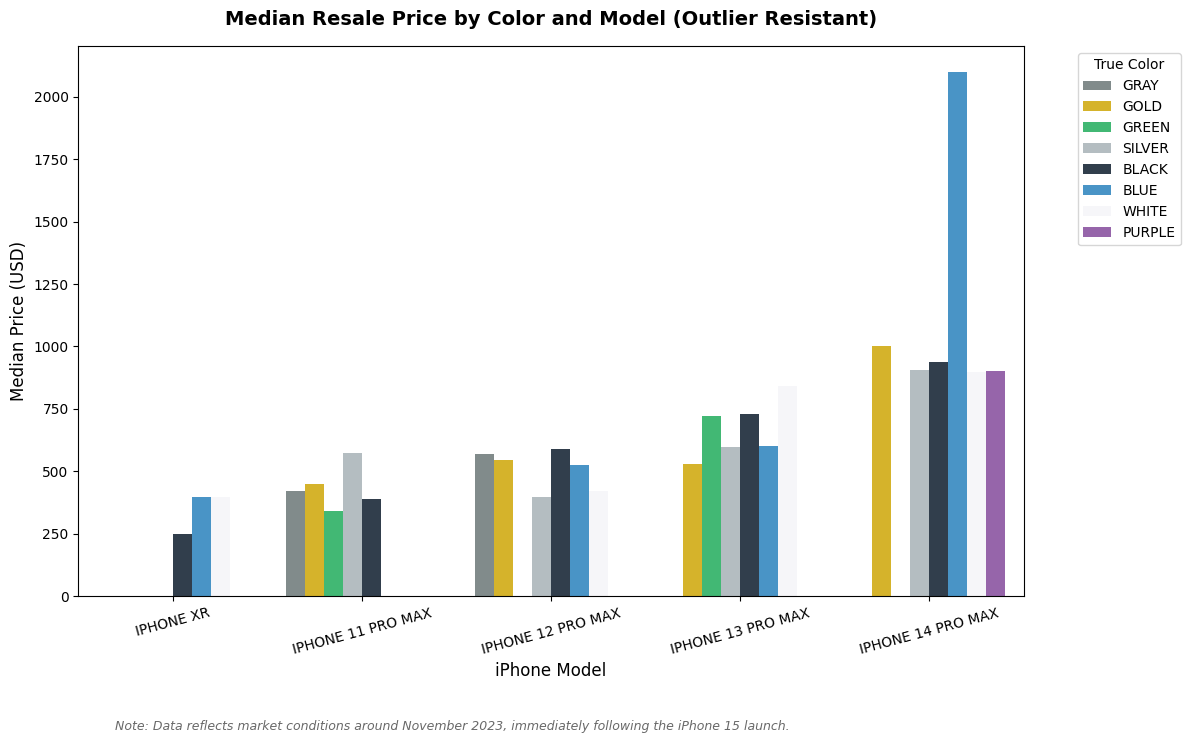

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a copy of the dataframe to work on safely
df_colors = df_totale.copy()

# List of colors to look for inside the 'Title' column
colors_to_track = ['BLACK', 'WHITE', 'GOLD', 'SILVER', 'PURPLE', 'GREEN', 'BLUE', 'GRAY']

# Extract color from the Title (case-insensitive check, defaults to 'UNKNOWN')
def extract_color(title):
    if not isinstance(title, str):
        return 'UNKNOWN'
    title_upper = title.upper()
    for color in colors_to_track:
        if color in title_upper:
            return color
    return 'UNKNOWN'

df_colors['Color_Extracted'] = df_colors['Title'].apply(extract_color)

# 2. Filter out rows where no tracked color was found
df_valid_colors = df_colors[df_colors['Color_Extracted'] != 'UNKNOWN'].copy()

# 3. Exact hex code mapping for the visualization palette
color_palette_custom = {
    'BLACK': '#2c3e50',       # Dark Anthracite
    'WHITE': '#f5f6fa',       # Off-white / Light Silver
    'GOLD': '#f1c40f',        # Gold
    'SILVER': '#b2bec3',      # Silver
    'PURPLE': '#9b59b6',      # Purple
    'GREEN': '#2ecc71',       # Green
    'BLUE': '#3498db',        # Blue
    'GRAY': '#7f8c8d'         # Gray
}

model_order = ['IPHONE XR', 'IPHONE 11 PRO MAX', 'IPHONE 12 PRO MAX', 'IPHONE 13 PRO MAX', 'IPHONE 14 PRO MAX']

# 4. Generate the Plot
plt.figure(figsize=(12, 7))

sns.barplot(
    data=df_valid_colors,
    x='Modello',
    y='Price_Clean',
    hue='Color_Extracted',
    order=model_order,
    palette=color_palette_custom,
    estimator=np.median,
    errorbar=None
)

# English titles and styling
plt.title('Median Resale Price by Color and Model (Outlier Resistant)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('iPhone Model', fontsize=12)
plt.ylabel('Median Price (USD)', fontsize=12)
plt.xticks(rotation=15)

# Move the legend outside
plt.legend(title='True Color', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

# English footnote
short_footnote = "Note: Data reflects market conditions around November 2023, immediately following the iPhone 15 launch."
plt.figtext(0.1, -0.05, short_footnote, fontsize=9, style='italic', color='dimgray')

plt.show()

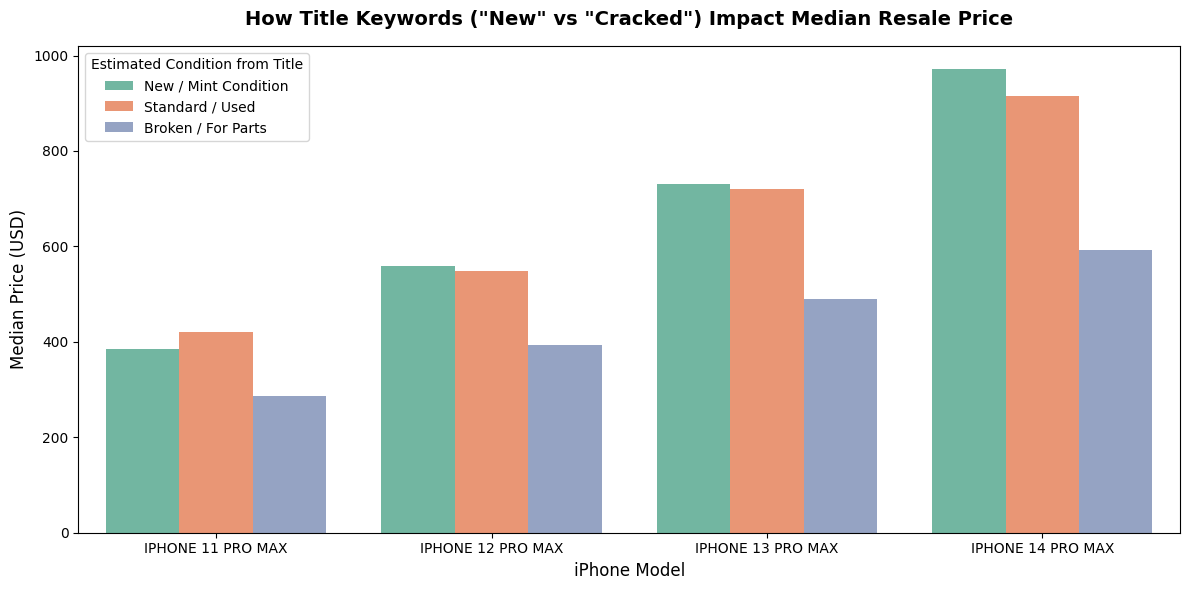

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creiamo delle colonne booleane per identificare lo stato del telefono dalle parole chiave
df_totale['Is_Broken'] = df_totale['Title'].str.upper().str.contains('CRACKED|PARTS|BROKEN|BAD', regex=True)
df_totale['Is_Mint'] = df_totale['Title'].str.upper().str.contains('NEW|MINT|SEALED|BRAND NEW', regex=True)

# Definiamo una categoria di stato basata sulle parole chiave
def definisci_stato(row):
    if row['Is_Broken']: return 'Broken / For Parts'
    if row['Is_Mint']: return 'New / Mint Condition'
    return 'Standard / Used'

df_totale['Estimated_Condition'] = df_totale.apply(definisci_stato, axis=1)

# Calcoliamo l'impatto sul prezzo medio (escludiamo l'XR per concentrarci sui Pro Max)
df_condition = df_totale[df_totale['Modello'] != 'IPHONE XR']

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_condition,
    x='Modello',
    y='Price_Clean',
    hue='Estimated_Condition',
    order=['IPHONE 11 PRO MAX', 'IPHONE 12 PRO MAX', 'IPHONE 13 PRO MAX', 'IPHONE 14 PRO MAX'],
    palette='Set2',
    estimator=np.median,
    errorbar=None
)

plt.title('How Title Keywords ("New" vs "Cracked") Impact Median Resale Price', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('iPhone Model', fontsize=12)
plt.ylabel('Median Price (USD)', fontsize=12)
plt.legend(title='Estimated Condition from Title')

plt.tight_layout()
plt.show()

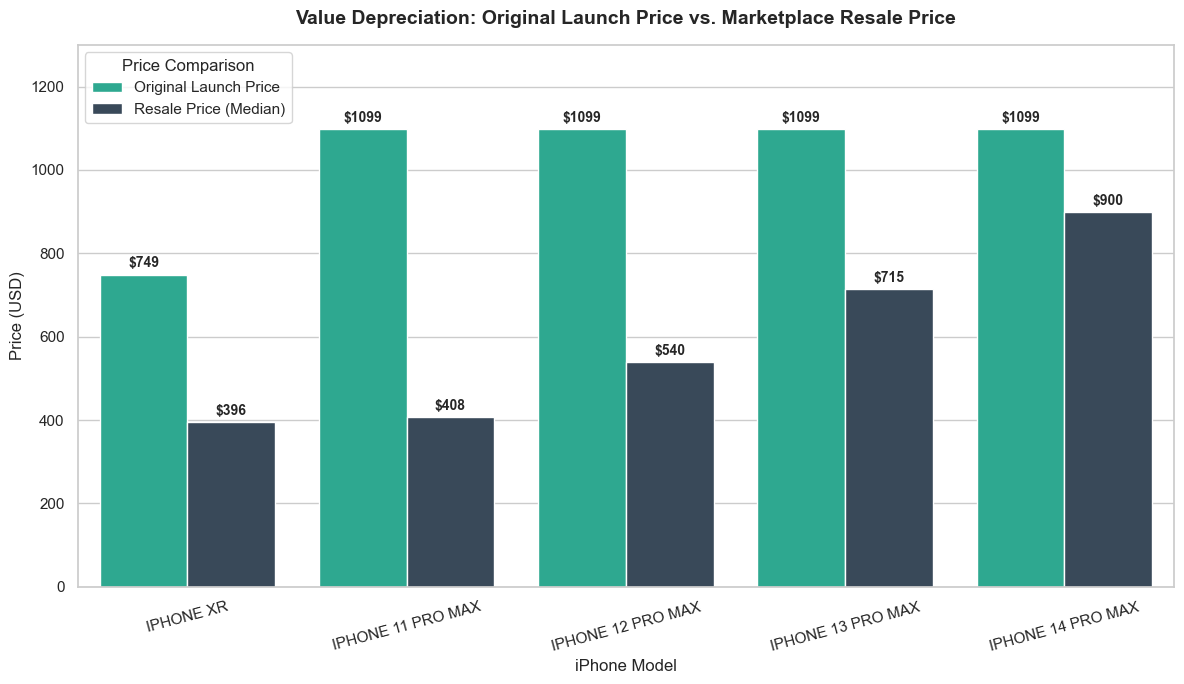

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Calculate our historical median prices from the dataset
df_medians = df_totale.groupby('Modello')['Price_Clean'].median().reset_index()

# 2. Map the official Apple US Launch Prices for the base versions
launch_prices = {
    'IPHONE XR': 749,
    'IPHONE 11 PRO MAX': 1099,
    'IPHONE 12 PRO MAX': 1099,
    'IPHONE 13 PRO MAX': 1099,
    'IPHONE 14 PRO MAX': 1099
}
df_medians['Launch_Price'] = df_medians['Modello'].map(launch_prices)

# 3. Reshape the data for side-by-side plotting (Melt format)
df_plot = pd.melt(df_medians, id_vars=['Modello'], value_vars=['Launch_Price', 'Price_Clean'],
                  var_name='Price_Type', value_name='Amount')

# Rename for clean legend labels
df_plot['Price_Type'] = df_plot['Price_Type'].replace({'Launch_Price': 'Original Launch Price', 'Price_Clean': 'Resale Price (Median)'})

# 4. Generate the visualization
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

ordine_modelli = ['IPHONE XR', 'IPHONE 11 PRO MAX', 'IPHONE 12 PRO MAX', 'IPHONE 13 PRO MAX', 'IPHONE 14 PRO MAX']

ax = sns.barplot(
    data=df_plot,
    x='Modello',
    y='Amount',
    hue='Price_Type',
    order=ordine_modelli,
    palette=['#1abc9c', '#34495e'] # Teal for Launch, Dark Slate for Resale
)

plt.title('Value Depreciation: Original Launch Price vs. Marketplace Resale Price', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('iPhone Model', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.xticks(rotation=15)
plt.ylim(0, 1300)
plt.legend(title='Price Comparison')

# Add data labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"${height:.0f}", (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()